# Behavior Modeling API: LimSim Implementation

## Introduction

Tactics2D provides unified reimplementations of a collection of representative traffic participant behavior models to support the development, validation, and testing of Autonomous Driving Systems (ADS) with realistic and scalable traffic interactions. LimSim is one of the default behavior models integrated into Tactics2D.

Original paper: [LimSim: A Long-term Interactive Multi-scenario Traffic Simulator](https://arxiv.org/abs/2307.06648)

Original code: [PJLab-ADG/LimSim](https://github.com/PJLab-ADG/LimSim)

LimSim adopts a hierarchical Prediction–Decision-making–Planning (PDP) framework that decomposes vehicle behavior generation into three sequential stages: prediction, decision-making, and planning. To efficiently model multi-agent interactions, LimSim first partitions globally interacting vehicles into interaction groups and then performs joint decision-making within each group using a group-based Monte Carlo Tree Search (MCTS) algorithm. This hierarchical design enables long-term, interactive traffic simulation while maintaining computational efficiency.

The original paper validates LimSim on both the Waymo Open Motion Dataset (WOMD) and CitySim, demonstrating its capability for long-term interactive traffic simulation across multiple urban scenarios. Rather than reproducing only these benchmark settings, Tactics2D reimplements LimSim on top of its unified data representation, map abstraction, and scenario interface. Consequently, the behavior model can be executed on all datasets supported by Tactics2D, making LimSim one of the framework's default foundational behavior models and providing a consistent behavior generation pipeline across heterogeneous traffic datasets.

In this documentation, we will demonstrate how to use the LimSim behavior model in Tactics2D with all built-in modules and datasets.

## Environment Setup

Please install Tactics2D (`pip install 'tactics2[behavior]'`) or add the Tactics2D source directory to your `PYTHONPATH`. See the [Installation Guide](https://tactics2d.readthedocs.io/en/latest/installation/) for more details.

## Dataset Preparation

Tactics2D does not require datasets to be stored in a fixed location. You can place a dataset in any directory and provide its path when loading it. Throughout this tutorial, **WOMD** is used to demonstrate the standard workflow of LimSim, while **HighD, InD** serves as an additional example to show how LimSim can be used with other datasets supported by Tactics2D.

## Use LimSim for Behavior Generation

The pipeline below demonstrates a complete LimSim takeover visualization. Every step that interacts with data (parsing, representing, predicting, and rendering) is handled by Tactics2D's public API. The notebook only provides glue code.

| Module | Key API |
|--------|---------|
| **Dataset parsers** | `parser.parse_trajectory(...)` → `(participants, time_range)` |
| **Map abstraction** | `map_.roadlines`, `map_.lanes`, `map_.areas` |
| **Participant model** | `participant.trajectory.get_state(frame)` |
| **Behavior model** | `model.predict(participants, map_, frame, agent_ids)` → `{agent_id: Trajectory}` |
| **BEVCamera** | `camera.update(frame, participants, ...)` → `geometry_data` |
| **MatplotlibRenderer** | `renderer.update(geometry_data)` |
| **Trajectory gradient** | `renderer.draw_gradient_trace(positions, colormap)` |
| **Color & style** | `participant.color = "purple"` overrides `COLOR_PALETTE` defaults |

In [1]:
%matplotlib notebook

import warnings

warnings.filterwarnings("ignore")

import logging

logging.basicConfig(level=logging.WARNING)

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from tactics2d.dataset_parser import WOMDParser, LevelXParser, extract_all_lane_sequences
from tactics2d.behavior import LimSimBehaviorModel, LimSimConfig
from tactics2d.map.parser import OSMParser
from tactics2d.map.element import Map
from tactics2d.map.map_config import HIGHD_MAP_CONFIG, IND_MAP_CONFIG

from tutorial_common import apply_notebook_style, render_replay_animation, select_ego

apply_notebook_style()
sns.set_palette("husl")

pygame 2.6.1 (SDL 2.28.4, Python 3.10.20)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [2]:
# LimSim model config (balanced_demo ≈ original paper defaults)
LIMSIM_CFG = LimSimConfig(
    horizon_steps=50,
    dt=0.1,
    mcts_iterations=200,
    terminal_depth=4,
    interaction_distance=30.0,
    max_group_size=3,
    use_frenet_refinement=False,
)

# Prediction / display constants. The perception range and view window are shared
# with the other behavior demos and live in tutorial_common.
NUM_SECONDS = 20  # how many seconds of playback
MAX_WORKERS = 8  # parallel predict threads

## Usage

The following three steps demonstrate a reusable pipeline for visualizing LimSim's predicted trajectories. Each step describes the relevant built-in modules provided by Tactics2D and how they are combined in the example code. For simplicity, this demo takes over only **one vehicle** at a time. To control multiple vehicles simultaneously, simply pass a list of agent IDs to the `model.predict()` function.

### Step 1: Select the Takeover Vehicle

`Vehicle` carries a `Trajectory` (a `dict[int, State]` mapping timestamps to positions) and a `color` attribute consumed by the renderer. `select_ego` picks a vehicle that is already present before the warm-up frame and that survives into the second half of the scenario - the closest local proxy for the "vehicle to take over" role. The helper is shared by all three behavior demos and lives in `tutorial_common.py` next to this notebook; pass `ego_id` to `run_takeover_scenario` to override it, which is what the examples below do.

The color is resolved against `COLOR_PALETTE` — `"purple"` → `#8854d0`, the same mechanism that maps vehicle types to default colors.

### Step 2: Predict Trajectories with LimSim

`LimSimBehaviorModel` wraps the PDP framework (prediction → decision → planning) behind a single call shared by all Tactics2D behavior models:

```python
predicted = model.predict(participants, map_, frame=frame, agent_ids=[ego_id])
```

- `participants` — the same dict from `parse_trajectory()`; each `Vehicle`'s history states up to `frame` are the model's input.
- `map_` — the `Map` from `parse_map()`, providing lane, roadline, and area geometry.
- `agent_ids` — which participants to predict for; others are still observed as context.

Returns `{agent_id: Trajectory}` with predicted future states using the same `.get_state(frame)` API as history.

For multi-frame prediction, use the built-in `predict_batch()` method, which dispatches frames across a `ThreadPoolExecutor` when `parallel_workers` > 1:

```python
model = LimSimBehaviorModel(config, parallel_workers=8)
frame_predictions = model.predict_batch(participants, map_, playback_frames, agent_ids=[ego_id])
```

### Step 3: Render with BEVCamera and MatplotlibRenderer

The animation comes from `tutorial_common.render_replay_animation`, the same helper the BITS and InterSim demos call. It owns the display wiring: a **BEVCamera** for viewport culling and geometry generation (`camera.update(...)` returns `(geometry_data, road_set, participant_set)`, which the renderer consumes directly), a **MatplotlibRenderer** that draws with automatic z-ordering (road areas < lines < buildings < vehicles < point clouds) and resolves colors from `COLOR_PALETTE` and `DEFAULT_COLOR` by element type, the ego-following camera window, and the trajectory gradient traces.

**Trajectory gradient** (`renderer.enable_trajectory_gradient()` + `draw_gradient_trace()`) renders colormapped past/future traces at zorder 5 — near segments get the dark end, far segments the light end.

Two traces are drawn: the **BuPu** trace is the path the ego has already driven (reversed, so the closest point comes first), and the **GnBu** trace is the plan the model is currently working from. Plans are stored as absolute waypoints keyed by the frame that issued them, so the helper clips each trace to the part of the plan the ego has not driven yet and the trace always reads forward from the ego.

The playback rate is a parameter: each dataset reports its own frame spacing, so the examples below pass the default `fps=10` for the WOMD recording and `fps=25` for the HighD and inD recordings parsed at 25 Hz.

In [3]:
def run_takeover_scenario(
    parser,
    file_name=None,
    folder=None,
    map_path=None,
    map_config=None,
    ego_id=None,
    ego_color="light-pink",
    fps=10,
    num_seconds=NUM_SECONDS,
    resolution=(1200, 800),
    **parse_kwargs,
):
    print("Parsing scenario ...")
    participants, time_range = parser.parse_trajectory(
        file=file_name, folder=folder, **parse_kwargs
    )

    map_ = None
    if hasattr(parser, "parse_map"):
        map_ = parser.parse_map(file=file_name, folder=folder, **parse_kwargs)
    if map_ is None and map_path is not None:
        print(f"  loading map from {map_path}")
        map_ = OSMParser(lanelet2=True).parse(file_path=map_path, configs=map_config)
    if map_ is None:
        map_ = Map("empty_map", scenario_type="demo")

    print(f"  participants: {len(participants)},  frames: {time_range}")
    if ego_id is None:
        ego_id = select_ego(participants)
    participants[ego_id].color = ego_color
    print(f"  takeover target: {ego_id}  (color: {ego_color})")

    # ---- prepare takeover window ----
    ego = participants[ego_id]
    frames = sorted(ego.trajectory.history_states.keys())
    takeover_idx = min(int(fps * 1.0), len(frames) // 5)
    takeover = frames[takeover_idx]
    hist_n = takeover_idx

    orig_hist = dict(ego.trajectory.history_states)
    orig_ego_frames = sorted(orig_hist.keys())

    def _truncate(at):
        ego.trajectory._history_states = {f: s for f, s in orig_hist.items() if f <= at}
        ego.trajectory._frames = sorted(ego.trajectory._history_states.keys())

    _truncate(takeover)

    # ---- extract lane sequences for the ego vehicle only ---
    route_map = extract_all_lane_sequences(participants, map_, takeover, agent_ids=[ego_id])
    if route_map:
        routed = sum(1 for v in route_map.values() if len(v) > 1)
        print(f"  route_map: {len(route_map)} vehicles ({routed} with multi-lane routes)")

    # ---- receding-horizon MPC ----
    model = LimSimBehaviorModel(LIMSIM_CFG)
    mpc_xs, mpc_ys, mpc_ts, mpc_plans = [], [], [], {}
    cur = takeover
    dt_ms = int(LIMSIM_CFG.dt * 1000)
    total_cycles = int(num_seconds * 1000 / dt_ms)
    window_end = takeover + int(num_seconds * 1000)

    for _ in range(total_cycles):
        try:
            pred = model.predict(participants, map_, cur, agent_ids=[ego_id], route_map=route_map)
        except Exception:
            break
        if ego_id not in pred:
            break
        pt = pred[ego_id]
        ff = [f for f in pt.frames if f > cur]
        if not ff:
            break

        first_f, first_s = ff[0], pt.get_state(ff[0])
        # Absolute world coordinates, keyed by the frame each plan was issued at;
        # the renderer clips them to the part the ego has not driven yet.
        mpc_plans[cur] = [(f, pt.get_state(f).x, pt.get_state(f).y) for f in ff]
        mpc_xs.append(first_s.x)
        mpc_ys.append(first_s.y)
        mpc_ts.append(first_f)

        if ego.trajectory.has_state(first_f):
            ego.trajectory._history_states[first_f] = first_s
        else:
            ego.trajectory.add_state(first_s)
        cur = first_f

    total_simulated_s = (mpc_ts[-1] - takeover) / 1000 if mpc_ts else 0.0
    print(
        f"  MPC: {len(mpc_ts)} cycles over {total_simulated_s:.1f}s  " f"(planned {num_seconds}s)"
    )

    # ---- interpolate MPC to original frame grid (capped at num_seconds) ----
    _truncate(takeover)
    target = [f for f in orig_ego_frames if takeover < f <= window_end]
    StateCls = type(ego.trajectory.get_state(takeover))

    if len(target) > 0 and len(mpc_ts) >= 1:
        if len(mpc_ts) >= 2:
            ix = np.interp(target, mpc_ts, np.array(mpc_xs))
            iy = np.interp(target, mpc_ts, np.array(mpc_ys))
        else:
            ix = np.full(len(target), mpc_xs[0])
            iy = np.full(len(target), mpc_ys[0])
        h = ego.trajectory.get_state(takeover).heading
        for i, (t, x, y) in enumerate(zip(target, ix, iy)):
            if i < len(target) - 1:
                dx, dy = ix[i + 1] - x, iy[i + 1] - y
                if abs(dx) > 1e-6 or abs(dy) > 1e-6:
                    h = np.arctan2(dy, dx)
            ego.trajectory.add_state(StateCls(frame=t, x=x, y=y, heading=float(h)))

    # ---- build playback frames: 1s history + MPC window ----
    all_frames = frames[takeover_idx - hist_n : takeover_idx] + target
    print(
        f"  playback: {len(all_frames)} frames  "
        f"({all_frames[0]}-{all_frames[-1]})  "
        f"(~{(all_frames[-1] - all_frames[0]) / 1000:.0f}s)"
    )

    # ---- render ----
    ani = render_replay_animation(
        participants,
        map_,
        all_frames,
        ego_id,
        plans=mpc_plans,
        resolution=resolution,
        fps=fps,
        title_prefix="LimSim takeover",
    )

    return ani

### Example 1: WOMD — 234dfbe99b740c80

This example demonstrates how LimSim takes over selected vehicles in a WOMD scenario by replacing their future trajectories with model predictions. In the animation below, the ego vehicle is shown in pink, its ground-truth trajectory in purple, and the trajectory predicted by LimSim in blue. The takeover is triggered 1 second after the scenario begins, using the ego vehicle's previous 1 second of motion history as input for prediction.

In [4]:
ani_womd = run_takeover_scenario(
    WOMDParser(),
    scenario_id="234dfbe99b740c80",
    file_name=(
        "uncompressed_scenario_validation_interactive_"
        "validation_interactive.tfrecord-00000-of-00150"
    ),
    folder="../../data/WOMD",
    ego_id=364,
)
ani_womd

Parsing scenario ...
  participants: 55,  frames: (0, 8997)
  takeover target: 364  (color: light-pink)
  route_map: 1 vehicles (0 with multi-lane routes)
  MPC: 200 cycles over 20.0s  (planned 20s)
  playback: 90 frames  (0-8997)  (~9s)


### Example 2: HighD (LevelX) — Location 1

HighD uses `LevelXParser("highD")` at 25 Hz on German highway recordings. The map is a lanelet2 `.osm` file parsed with `OSMParser` and `HIGHD_MAP_CONFIG`.  Files 01–06 map to location 1 (`highD_1`). Highway speeds (~30 m/s) produce visibly longer MPC plans than urban datasets like InD.  

Adjust the paths below to match your local data layout.

In [5]:
ani_highd = run_takeover_scenario(
    LevelXParser("highD"),
    file_name=11,
    folder="../../data/highD/data",
    map_path="../../data/highD_map/highD_1.osm",
    map_config=HIGHD_MAP_CONFIG["highD_1"],
    ego_id=18,
    fps=25,
)
ani_highd

Parsing scenario ...


  loading map from ../../data/highD_map/highD_1.osm
  participants: 1776,  frames: (np.int64(40), np.int64(611080))
  takeover target: 18  (color: light-pink)
  route_map: 1 vehicles (0 with multi-lane routes)
  MPC: 200 cycles over 20.0s  (planned 20s)
  playback: 240 frames  (40-9640)  (~10s)


### Example 3: inD (LevelX) — Location 1

This example demonstrates LimSim on the **inD** dataset using `LevelXParser("inD")`, which processes the data at **25 Hz**. The road network is loaded from a Lanelet2 `.osm` map using `OSMParser` together with `IND_MAP_CONFIG`. Recordings **00–06** correspond to **Location 1** (`inD_1`), **07–17** to **Location 2**, and the remaining recordings to the other inD locations.

In this scenario, the ego vehicle approaches an intersection where the intentions of surrounding vehicles are ambiguous. To ensure safe interaction under this uncertainty, LimSim keeps the controlled vehicle stationary until a safe maneuver can be determined.

In [6]:
ani_ind = run_takeover_scenario(
    LevelXParser("inD"),
    file_name=7,
    folder="../../data/inD/data",
    map_path="../../data/inD_map/inD_1.osm",
    map_config=IND_MAP_CONFIG["inD_1"],
    ego_id=12,
    fps=25,
)
ani_ind

Parsing scenario ...
  loading map from ../../data/inD_map/inD_1.osm
  participants: 212,  frames: (np.int64(0), np.int64(1055240))
  takeover target: 12  (color: light-pink)


  route_map: 1 vehicles (0 with multi-lane routes)
  MPC: 200 cycles over 20.0s  (planned 20s)
  playback: 161 frames  (10240-16680)  (~6s)


### Quick Configurations

The table below offers three preset configurations for common use cases.  The
**balanced_demo** preset reproduces the original LimSim paper's parameterisation:
``max_group_size=3`` (hardcoded in the original), MCTS base budget 200 with the
``200/(t/2+1)`` decay schedule (totalling ~513 iterations over 4 decision steps),
a 6 s decision horizon (``terminal_depth=4 × 1.5 s``), and a 5 s trajectory
(``horizon_steps=50`` at ``dt=0.1 s``).  Tactics2D's chained MCTS (v1.0) applies
the same decaying budget across ``terminal_depth`` sequential searches.

| Use Case | Key Settings |
|----------|-------------|
| **Fast preview** | ``mcts_iterations=50``, ``terminal_depth=3``, ``horizon_steps=30``, ``max_group_size=2``, ``interaction_distance=20`` |
| **Balanced demo** (≈ paper) | ``mcts_iterations=200``, ``terminal_depth=4``, ``horizon_steps=50``, ``max_group_size=3``, ``interaction_distance=30`` |
| **High-fidelity eval** | ``mcts_iterations=400``, ``terminal_depth=4``, ``horizon_steps=80``, ``max_group_size=3``, ``interaction_distance=50`` |

!!! info "Chained MCTS budget"
    Each preset runs ``terminal_depth`` sequential MCTS searches with a decaying
    budget ``base / (depth/2 + 1)``.  For balanced_demo (base = 200):
    depth 0 → 200, depth 1 → 133, depth 2 → 100, depth 3 → 80 (total ~513).
    The immediate next action always receives the most computation.

## Performance Analysis (TODO)

In [7]:
def plot_benchmark_analysis(df, datasets=None, configs=None, max_active=50):
    # Defaults live here so this cell is runnable on its own.
    datasets = datasets or ["highD", "inD", "rounD", "WOMD"]
    configs = configs or ["fast_preview", "balanced_demo", "high_fidelity"]
    cfg_markers = {"fast_preview": "o", "balanced_demo": "s", "high_fidelity": "^"}
    cfg_colors = dict(zip(configs, sns.color_palette()))
    METRICS = {
        "pred_time_s": ("prediction time (s)", None),
        "collision_pairs": ("collision rate", None),
    }
    YLIM = {0: (0.0, 0.1), 1: (0.0, 0.01)}
    fig, axes = plt.subplots(len(datasets), 2, figsize=(12, 3 * len(datasets)))
    for row, ds in enumerate(datasets):
        sub = df[df["dataset"] == ds]
        for col, (key, (ylabel, _)) in enumerate(METRICS.items()):
            ax = axes[row, col]
            for cfg in configs:
                cfg_sub = sub[sub["config"] == cfg]
                # filter: only use data points with avg_active_vehicles <= max_active
                cfg_sub = cfg_sub[cfg_sub["avg_active_vehicles"] <= max_active]
                x = cfg_sub["avg_active_vehicles"].values
                if key == "collision_pairs":
                    total = cfg_sub["total_pairs"].values
                    y = np.divide(
                        cfg_sub["collision_pairs"].values,
                        total,
                        out=np.zeros_like(total, dtype=float),
                        where=total > 0,
                    )
                else:
                    y = cfg_sub[key].values
                if len(x) < 3:
                    continue
                ax.scatter(
                    x,
                    y,
                    c=[cfg_colors[cfg]],
                    alpha=0.2,
                    s=16,
                    marker=cfg_markers[cfg],
                    edgecolors="none",
                )
                idx = np.argsort(x)
                p = np.poly1d(np.polyfit(x[idx], y[idx], 2))
                xl = np.linspace(x.min(), x.max(), 80)
                yl = p(xl)
                ax.plot(xl, yl, c=cfg_colors[cfg], lw=2, label=cfg.replace("_", " "))
            ax.set_xlabel("avg active participants")
            ax.set_ylabel(ylabel)
            ax.set_title(f"{ds} — {ylabel}")
            ax.set_ylim(*YLIM[col])
            if row == 0 and col == 0:
                ax.legend(fontsize=7, ncol=3, loc="upper left")
    fig.tight_layout(pad=2)
    return fig

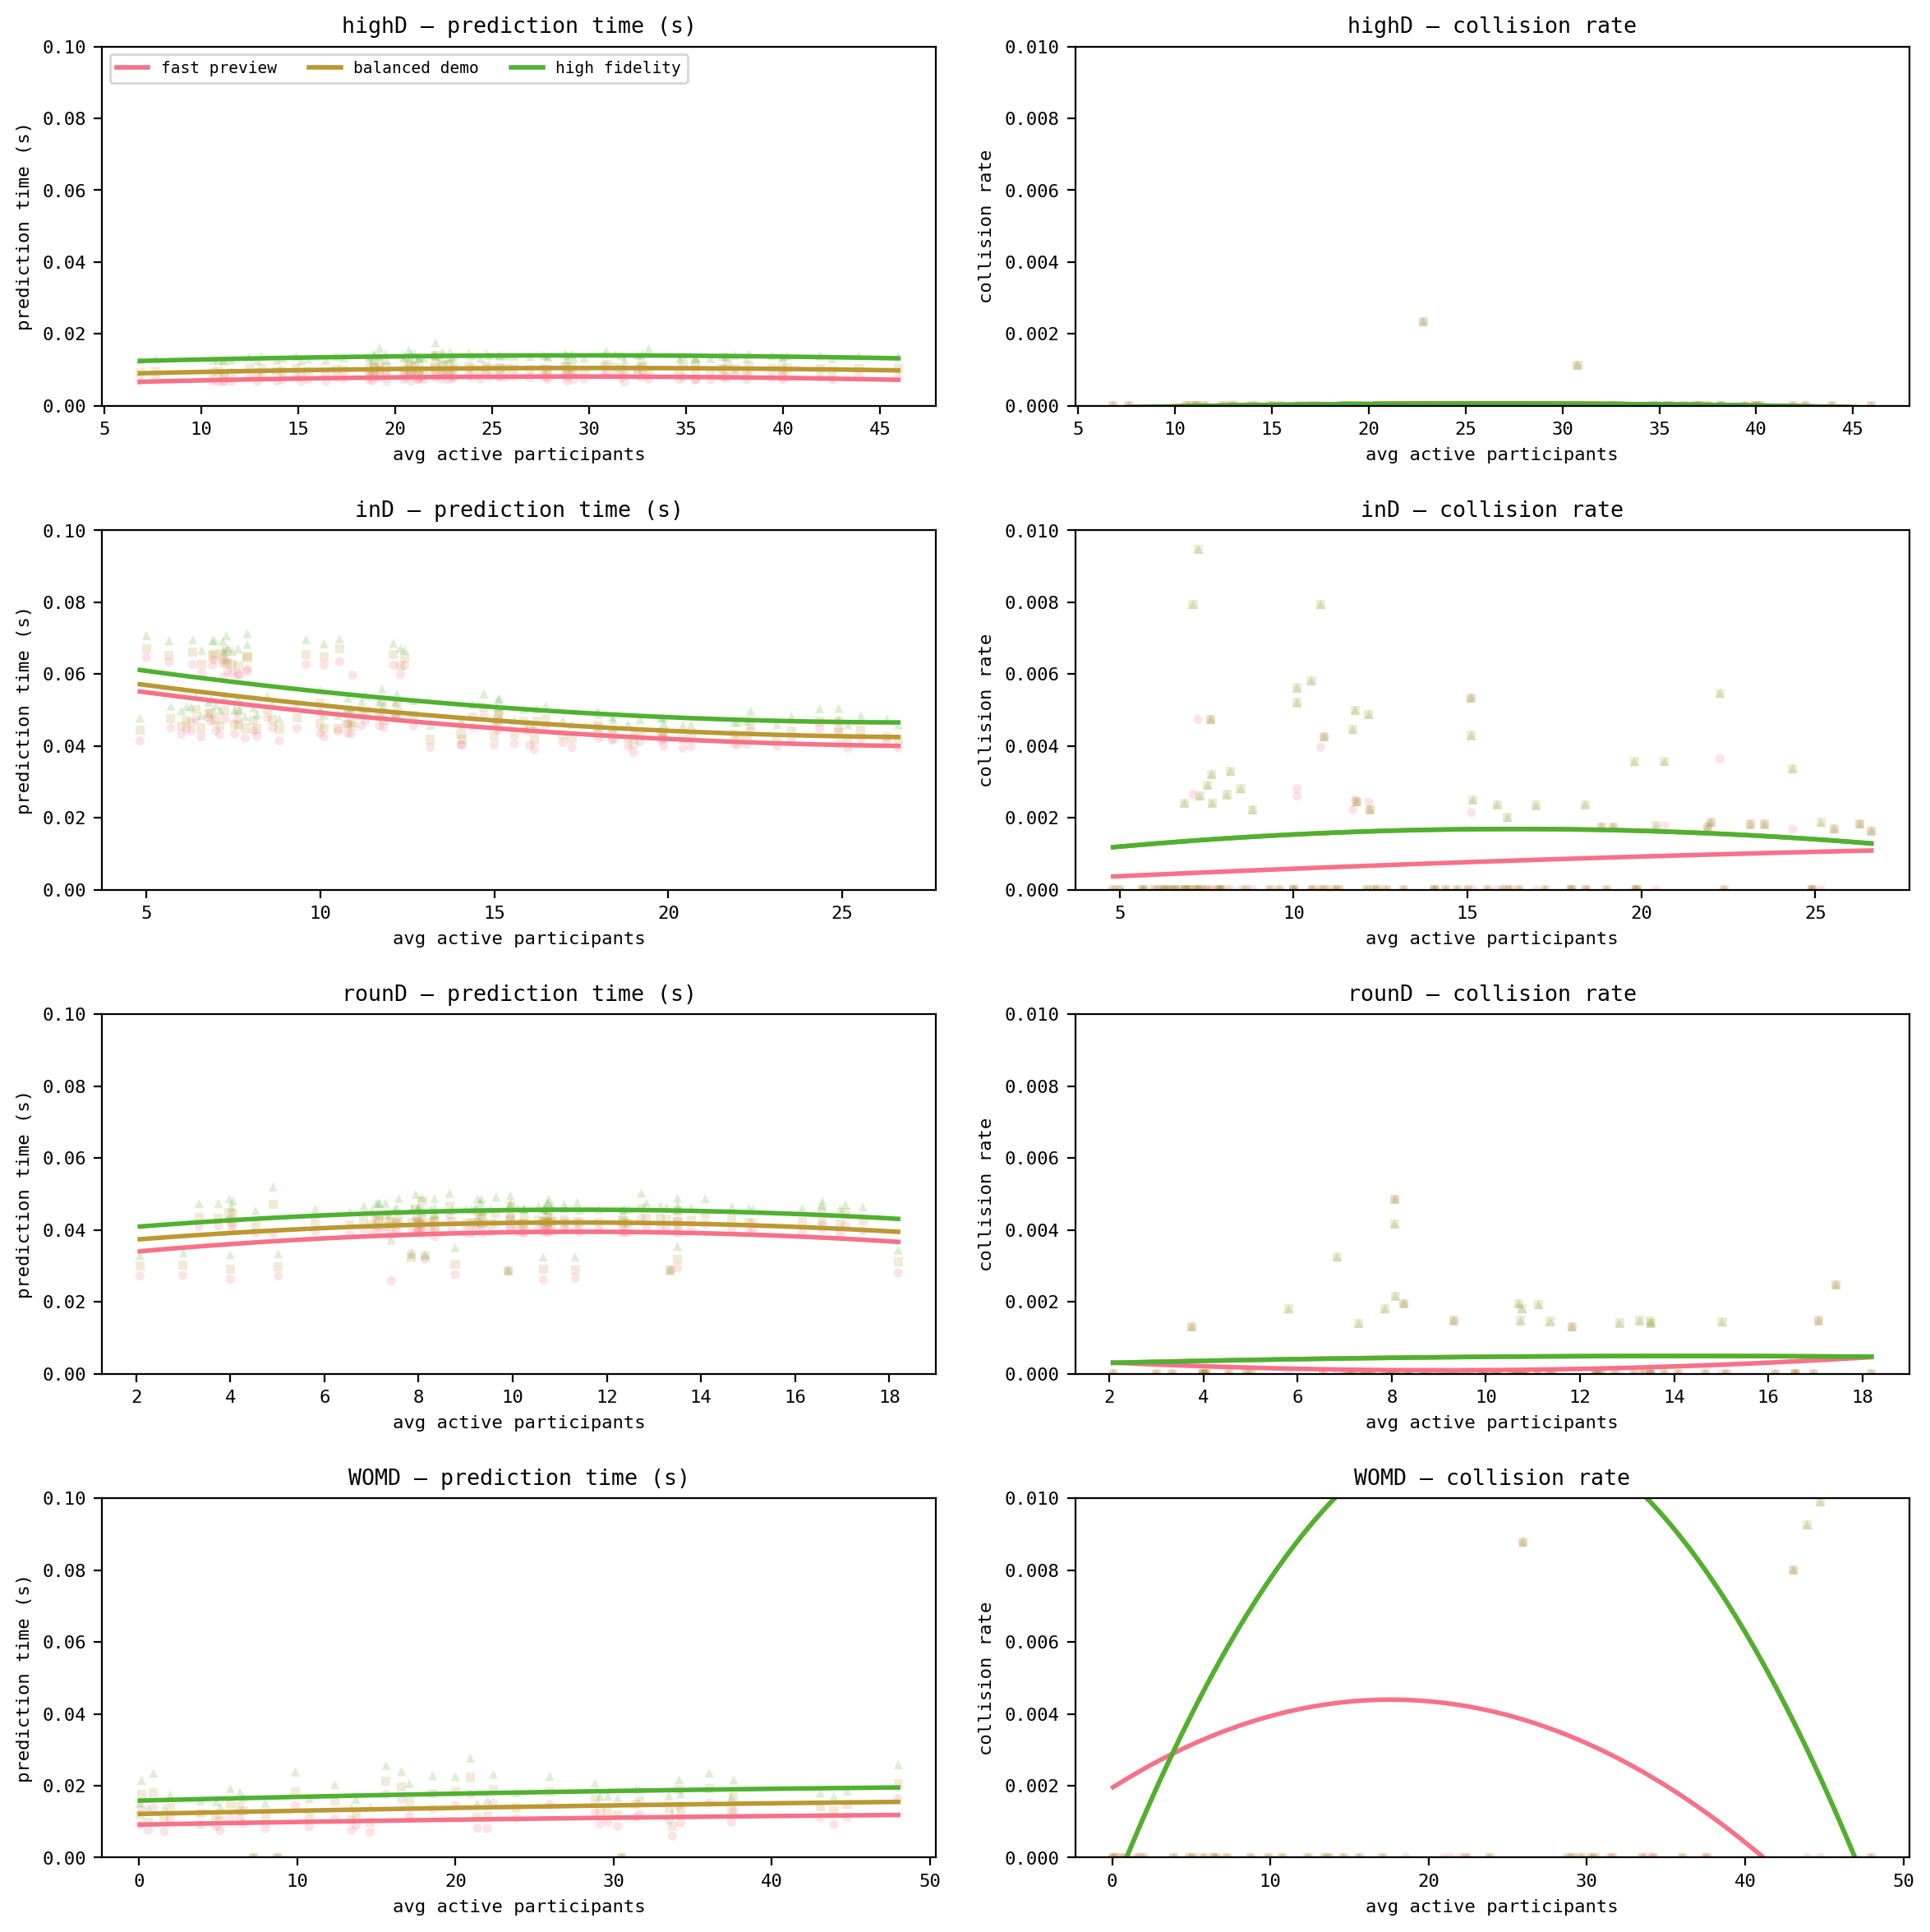

In [8]:
df = pd.read_csv("../../data/limsim_summary.csv")
plot_benchmark_analysis(df)